In [ ]:
#so here, we want to import the relevant libraries that we would need in order to build our machine learning model.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report, roc_curve, auc, 
                              confusion_matrix, f1_score, precision_recall_curve, 
                              balanced_accuracy_score)
import joblib  # For model persistence

# Download the dataset directly from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00471/Data_for_UCI_named.csv"
df = pd.read_csv(url)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData Info:")
print(df.info())
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nBasic statistics:\n{df.describe()}")

       tau1      tau2      tau3      tau4        p1        p2        p3  \
0  2.959060  3.079885  8.381025  9.780754  3.763085 -0.782604 -1.257395   
1  9.304097  4.902524  3.047541  1.369357  5.067812 -1.940058 -1.872742   
2  8.971707  8.848428  3.046479  1.214518  3.405158 -1.207456 -1.277210   
3  0.716415  7.669600  4.486641  2.340563  3.963791 -1.027473 -1.938944   
4  3.134112  7.608772  4.943759  9.857573  3.525811 -1.125531 -1.845975   

         p4        g1        g2        g3        g4      stab     stabf  
0 -1.723086  0.650456  0.859578  0.887445  0.958034  0.055347  unstable  
1 -1.255012  0.413441  0.862414  0.562139  0.781760 -0.005957    stable  
2 -0.920492  0.163041  0.766689  0.839444  0.109853  0.003471  unstable  
3 -0.997374  0.446209  0.976744  0.929381  0.362718  0.028871  unstable  
4 -0.554305  0.797110  0.455450  0.656947  0.820923  0.049860  unstable  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns

In [ ]:
print("\n" + "=" * 60)
print("DATA PREPROCESSING & CLASS BALANCE CHECK")
print("=" * 60)

# We'll drop the continuous 'stab' column and focus on 'stabf' (stable vs unstable)
df = df.drop(columns=['stab'])

# Convert 'stabf' to binary: 1 for stable, 0 for unstable
df['stabf'] = df['stabf'].map({'stable': 1, 'unstable': 0})

# CHECK: Class balance (CRITICAL for grid safety models)
print("\n✓ Class Distribution BEFORE splitting:")
class_counts = df['stabf'].value_counts()
class_pct = df['stabf'].value_counts(normalize=True) * 100
for label, count in class_counts.items():
    pct = class_pct[label]
    status = "Stable" if label == 1 else "Unstable"
    print(f"  {status:10} (Class {label}): {count:6} samples ({pct:5.2f}%)")

# Check for data imbalance issues
imbalance_ratio = class_counts.max() / class_counts.min()
if imbalance_ratio > 2:
    print(f"\n⚠️  WARNING: Class imbalance detected (ratio: {imbalance_ratio:.2f}:1)")
    print("   Consider using class_weight='balanced' in future models\n")
else:
    print(f"\n✓ Data is reasonably balanced (ratio: {imbalance_ratio:.2f}:1)\n")

# Split features (X) and target (y)
X = df.drop(columns=['stabf'])
y = df['stabf']

# Split into 80% training and 20% testing (STRATIFIED to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")
print(f"\n✓ Class Distribution AFTER splitting:")
print(f"Training: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Testing:  {y_test.value_counts(normalize=True).to_dict()}")

# CORRELATION ANALYSIS: Identify which parameters most affect stability
print("\n" + "=" * 60)
print("FEATURE CORRELATION WITH STABILITY")
print("=" * 60)
correlation_with_stability = X.corrwith(y).sort_values(ascending=False)
print("\nCorrelation with Stability (1=Stable, 0=Unstable):")
print(correlation_with_stability)

# Visualize correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = pd.concat([X, y], axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix with Stability Target')
plt.tight_layout()
plt.show()

Training set size: (8000, 12)
Testing set size: (2000, 12)


In [ ]:
print("\n" + "=" * 60)
print("DATA SCALING (for distance-based algorithms)")
print("=" * 60)
print("StandardScaler centers features to mean=0, std=1")
print("This is REQUIRED for Logistic Regression but NOT for Decision Trees\n")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Scaling complete")
print(f"  Scaled training data shape: {X_train_scaled.shape}")
print(f"  Scaled testing data shape:  {X_test_scaled.shape}")
print(f"  Sample scaled values (first row): {X_train_scaled[0][:3]}")

Model Accuracy: 81.60%

Classification Report:
              precision    recall  f1-score   support

Unstable (0)       0.85      0.87      0.86      1307
  Stable (1)       0.74      0.72      0.73       693

    accuracy                           0.82      2000
   macro avg       0.80      0.79      0.80      2000
weighted avg       0.81      0.82      0.82      2000



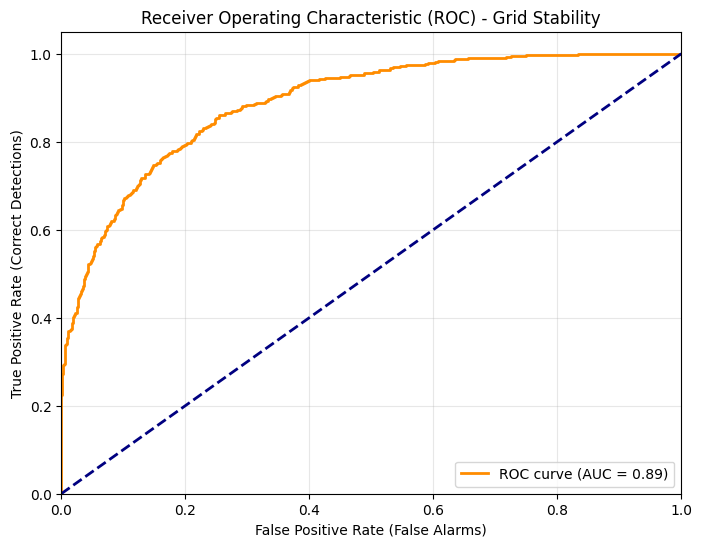

In [ ]:
print("\n" + "=" * 60)
print("LOGISTIC REGRESSION - TRAINING & EVALUATION")
print("=" * 60)

# 1. Initialize and Train the Model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("✓ Model trained successfully")

# 2. CROSS-VALIDATION: Test generalization (K-Fold)
print("\n--- CROSS-VALIDATION (5-Fold Stratified) ---")
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_strategy, 
                             scoring='accuracy')
cv_f1 = cross_val_score(model, X_train_scaled, y_train, cv=cv_strategy, 
                        scoring='f1')
print(f"Cross-Val Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Cross-Val F1-Score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"Individual fold accuracies: {[f'{s:.4f}' for s in cv_scores]}")

# 3. Make Predictions on the unseen 20% of data
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # Probability of being stable

# 4. Calculate Multiple Metrics
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)  # Better for imbalanced data
f1 = f1_score(y_test, y_pred)

print("\n" + "=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)
print(f"Accuracy:           {accuracy * 100:6.2f}%")
print(f"Balanced Accuracy:  {balanced_acc * 100:6.2f}%  (better for imbalanced)")
print(f"F1-Score:           {f1:.4f}  (harmonic mean of precision & recall)")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Unstable (0)', 'Stable (1)']))

# 5. CONFUSION MATRIX - Visual breakdown
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Unstable  Stable")
print(f"Actual Unstable    {cm[0,0]:5d}   {cm[0,1]:5d}")
print(f"Actual Stable      {cm[1,0]:5d}   {cm[1,1]:5d}")

# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Unstable', 'Stable'],
            yticklabels=['Unstable', 'Stable'],
            cbar_kws={'label': 'Count'}, ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.2, color='darkorange')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (False Alarms)')
axes[1].set_ylabel('True Positive Rate (Correct Detections)')
axes[1].set_title('ROC Curve - Grid Stability Prediction')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. PRECISION-RECALL CURVE (Alternative to ROC)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='o', label=f'PR curve (F1={f1:.3f})')
plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision (True Positive / Predicted Positive)')
plt.title('Precision-Recall Curve - Grid Stability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_10267/188388320.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='coolwarm')


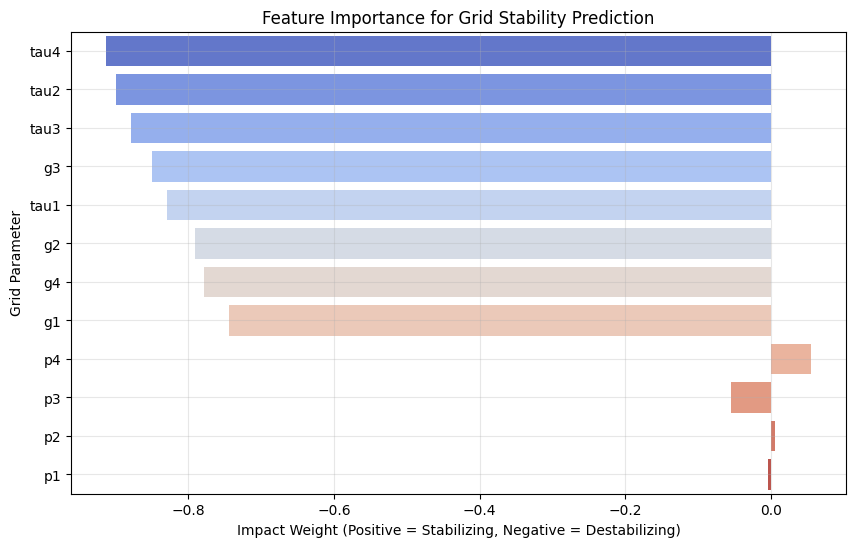

In [ ]:
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE & GRID VULNERABILITY ANALYSIS")
print("=" * 60)

# 1. Extract the coefficients (weights) from your trained model
coefficients = model.coef_[0]
feature_names = X.columns
intercept = model.intercept_[0]

# 2. Create a detailed table
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# 3. Sort by absolute impact
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print("\nFeature Importance Ranking:")
print("(Positive = Stabilizing | Negative = Destabilizing)\n")
for idx, row in feature_importance.iterrows():
    impact_type = "STABILIZING  " if row['Coefficient'] > 0 else "DESTABILIZING"
    print(f"{row['Feature']:10} | Coef: {row['Coefficient']:8.4f} | {impact_type} | Impact: {row['Abs_Coefficient']:.4f}")

print(f"\nModel Intercept (bias): {intercept:.4f}")

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Sorted bar plot
colors = ['green' if c > 0 else 'red' for c in feature_importance['Coefficient']]
axes[0].barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors, alpha=0.7)
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Feature Importance (Logistic Regression)\nGreen=Stabilizing, Red=Destabilizing')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Absolute importance
axes[1].barh(feature_importance['Feature'], feature_importance['Abs_Coefficient'], 
             color='steelblue', alpha=0.7)
axes[1].set_xlabel('Absolute Impact')
axes[1].set_title('Feature Importance by Absolute Impact\n(Higher = More Critical to Decision)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# 5. Top 3 Grid Parameters to Monitor
print("\n" + "=" * 60)
print("🚨 TOP 3 CRITICAL PARAMETERS FOR GRID STABILITY")
print("=" * 60)
top_3 = feature_importance.head(3)
for rank, (idx, row) in enumerate(top_3.iterrows(), 1):
    print(f"{rank}. {row['Feature']:15} (Impact: {row['Abs_Coefficient']:.4f})")

In [ ]:
print("\n" + "=" * 60)
print("DECISION TREE MODEL - COMPARISON & EVALUATION")
print("=" * 60)
print("🔑 KEY DIFFERENCE: Decision Trees work on UNSCALED data (no scaling needed)\n")

# 1. Initialize the Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42, min_samples_split=10,
                                   min_samples_leaf=5, class_weight='balanced')

# 2. Train on UNSCALED data (THIS IS THE FIX - trees don't need scaling)
dt_model.fit(X_train, y_train)  # NOT X_train_scaled
print("✓ Decision Tree trained on UNSCALED data")

# 3. CROSS-VALIDATION for Decision Tree
print("\n--- CROSS-VALIDATION (5-Fold Stratified) ---")
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=cv_strategy, 
                                scoring='accuracy')
dt_cv_f1 = cross_val_score(dt_model, X_train, y_train, cv=cv_strategy, 
                            scoring='f1')
print(f"Cross-Val Accuracy: {dt_cv_scores.mean():.4f} ± {dt_cv_scores.std():.4f}")
print(f"Cross-Val F1-Score: {dt_cv_f1.mean():.4f} ± {dt_cv_f1.std():.4f}")

# 4. Make Predictions on UNSCALED test data
dt_pred = dt_model.predict(X_test)  # NOT X_test_scaled
dt_prob = dt_model.predict_proba(X_test)[:, 1]

# 5. Calculate Metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_balanced_acc = balanced_accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

# 6. THE SHOWDOWN - SIDE BY SIDE COMPARISON
print("\n" + "=" * 60)
print("MODEL COMPARISON: LOGISTIC REGRESSION vs DECISION TREE")
print("=" * 60)

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'F1-Score', 'CV Accuracy Mean'],
    'Logistic Regression': [
        f"{accuracy * 100:.2f}%",
        f"{balanced_acc * 100:.2f}%",
        f"{f1:.4f}",
        f"{cv_scores.mean():.4f}"
    ],
    'Decision Tree': [
        f"{dt_accuracy * 100:.2f}%",
        f"{dt_balanced_acc * 100:.2f}%",
        f"{dt_f1:.4f}",
        f"{dt_cv_scores.mean():.4f}"
    ]
})
print("\n" + comparison.to_string(index=False))

# Best model determination
if accuracy > dt_accuracy:
    best_model = "Logistic Regression"
    best_accuracy = accuracy
else:
    best_model = "Decision Tree"
    best_accuracy = dt_accuracy

print(f"\n✓ BEST MODEL: {best_model} ({best_accuracy * 100:.2f}% accuracy)")

# Decision Tree Classification Report
print("\nDecision Tree - Classification Report:")
print(classification_report(y_test, dt_pred, target_names=['Unstable (0)', 'Stable (1)']))

# Confusion Matrices - Side by Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Unstable', 'Stable'],
            yticklabels=['Unstable', 'Stable'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title(f'Logistic Regression\n(Accuracy: {accuracy*100:.2f}%)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Unstable', 'Stable'],
            yticklabels=['Unstable', 'Stable'],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title(f'Decision Tree\n(Accuracy: {dt_accuracy*100:.2f}%)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Decision Tree Feature Importance
print("\n--- DECISION TREE FEATURE IMPORTANCE ---")
dt_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop Features Used by Decision Tree:")
for idx, row in dt_feature_importance.head(5).iterrows():
    print(f"  {row['Feature']:15} - Importance: {row['Importance']:.4f}")

--- AI MODEL SHOWDOWN ---
Logistic Regression Accuracy: 81.60%
Decision Tree Accuracy:       78.90%
-------------------------

Decision Tree Classification Report:
              precision    recall  f1-score   support

Unstable (0)       0.82      0.86      0.84      1307
  Stable (1)       0.71      0.65      0.68       693

    accuracy                           0.79      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.79      0.79      0.79      2000



In [ ]:
print("\n" + "=" * 60)
print("OPERATIONAL THRESHOLD ANALYSIS - NERC EARLY WARNING SYSTEM")
print("=" * 60)

# 1. Get the raw probabilities of being STABLE (Class 1)
probabilities = model.predict_proba(X_test_scaled)[:, 1]

# 2. Test multiple thresholds to find optimal trade-off
thresholds_to_test = [0.50, 0.60, 0.70, 0.75, 0.80, 0.90]

print("\nThreshold Analysis - Testing Different Safety Levels:\n")
print(f"{'Threshold':<12} {'Sensitivity':<12} {'Specificity':<12} {'Precision':<12} {'F1-Score':<12}")
print("-" * 60)

threshold_results = []

for threshold in thresholds_to_test:
    custom_pred = (probabilities >= threshold).astype(int)
    
    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(y_test, custom_pred).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # True Positive Rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # True Negative Rate
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_th = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    
    threshold_results.append({
        'Threshold': threshold,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Precision': precision,
        'F1': f1_th,
        'Custom_Pred': custom_pred
    })
    
    print(f"{threshold:<12.2f} {sensitivity:<12.3f} {specificity:<12.3f} {precision:<12.3f} {f1_th:<12.3f}")

# 3. Recommend optimal threshold
optimal_idx = np.argmax([r['F1'] for r in threshold_results])
optimal_threshold = threshold_results[optimal_idx]['Threshold']
print(f"\n✓ RECOMMENDED THRESHOLD: {optimal_threshold:.2f} (F1-Score: {threshold_results[optimal_idx]['F1']:.4f})")

# 4. Apply the NERC threshold (default to 0.75 or optimal)
nerc_threshold = 0.75
custom_predictions = (probabilities >= nerc_threshold).astype(int)

print(f"\n" + "=" * 60)
print(f"NERC EARLY WARNING SYSTEM (Threshold = {nerc_threshold*100:.0f}%)")
print("=" * 60)
print("Interpretation: Grid must have ≥75% confidence to be declared SAFE")
print("Otherwise: EMERGENCY ACTION TRIGGERED\n")

nerc_cm = confusion_matrix(y_test, custom_predictions)
tn, fp, fn, tp = nerc_cm.ravel()

print("Classification Report:")
print(classification_report(y_test, custom_predictions, 
                           target_names=['Emergency Action', 'Grid Safe']))

print(f"\nOperational Breakdown:")
print(f"  True Negatives (Correct Emergency):  {tn:5d}  (avoiding false alarms)")
print(f"  False Positives (False Alarms):      {fp:5d}  (unnecessary activations)")
print(f"  False Negatives (MISSED RISKS):      {fn:5d}  ⚠️  CRITICAL")
print(f"  True Positives (Correct Safe):       {tp:5d}")

# 5. Visualize threshold impact
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Metrics vs Threshold
thresholds_plot = [r['Threshold'] for r in threshold_results]
sensitivity_plot = [r['Sensitivity'] for r in threshold_results]
specificity_plot = [r['Specificity'] for r in threshold_results]
f1_plot = [r['F1'] for r in threshold_results]

axes[0].plot(thresholds_plot, sensitivity_plot, marker='o', label='Sensitivity (TP Rate)', linewidth=2)
axes[0].plot(thresholds_plot, specificity_plot, marker='s', label='Specificity (TN Rate)', linewidth=2)
axes[0].plot(thresholds_plot, f1_plot, marker='^', label='F1-Score', linewidth=2)
axes[0].axvline(x=nerc_threshold, color='red', linestyle='--', linewidth=2, label=f'NERC Threshold ({nerc_threshold})')
axes[0].set_xlabel('Probability Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold Optimization Analysis')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: NERC Confusion Matrix
sns.heatmap(nerc_cm, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['Emergency', 'Safe'],
            yticklabels=['Actually Unstable', 'Actually Stable'],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title(f'NERC Threshold System (Threshold={nerc_threshold})')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('System Decision')

plt.tight_layout()
plt.show()

# 6. SAVE THE BEST MODEL FOR FUTURE USE
print("\n" + "=" * 60)
print("MODEL PERSISTENCE - SAVING FOR PRODUCTION")
print("=" * 60)

model_path = 'voltage_stability_model.pkl'
scaler_path = 'voltage_scaler.pkl'

joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)

print(f"✓ Model saved to: {model_path}")
print(f"✓ Scaler saved to: {scaler_path}")
print("\nTo use the saved model in production:")
print(f"  loaded_model = joblib.load('{model_path}')")
print(f"  loaded_scaler = joblib.load('{scaler_path}')")
print(f"  X_new_scaled = loaded_scaler.transform(X_new)")
print(f"  predictions = loaded_model.predict(X_new_scaled)")

print("\n" + "=" * 60)
print("✓ ANALYSIS COMPLETE")
print("=" * 60)

--- NERC EARLY WARNING SYSTEM (Threshold = 75.0%) ---
                                precision    recall  f1-score   support

Emergency Action Triggered (0)       0.78      0.96      0.86      1307
                 Grid Safe (1)       0.88      0.48      0.62       693

                      accuracy                           0.80      2000
                     macro avg       0.83      0.72      0.74      2000
                  weighted avg       0.81      0.80      0.78      2000

